# Optical continuum slope of HD 93521 with HST/STIS

**Date:** 2026-07-31  
**Scientific question:** What power-law slope describes the calibrated optical continuum after masking strong lines?  
**Preserved source:** `../2026-07-31-hst-stis-hd93521-line-inventory/spectrum_subset.csv`

A hot star's optical spectrum lies toward the Rayleigh–Jeans side of its spectral
      energy distribution, but extinction and instrument calibration modify the observed slope.
      We fit log flux against log wavelength after masking known hydrogen and helium features.
      The fitted exponent is an empirical continuum descriptor, not a temperature measurement.

      STIS flux calibration is well characterised but finite; slit placement, extinction, line
      blanketing, and the limited 5300–10000 Å range remain important. Varying the line-mask
      width tests whether broad absorption features control the answer.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
spec=pd.read_csv("../2026-07-31-hst-stis-hd93521-line-inventory/spectrum_subset.csv").dropna(); spec=spec[(spec.flux>0)&(spec.error>0)].copy(); lines=np.array([5411.52,5875.62,6562.80,6678.15,7065.19]); print(f"Calibrated samples: {len(spec)} over {spec.wavelength_A.min():.0f}–{spec.wavelength_A.max():.0f} Å")

Calibrated samples: 567 over 5323–9993 Å


In [3]:
def fit_slope(width):
    keep=np.ones(len(spec),dtype=bool)
    for line in lines: keep &= np.abs(spec.wavelength_A-line)>width
    x=np.log(spec.loc[keep,"wavelength_A"]); y=np.log(spec.loc[keep,"flux"]); w=1/(spec.loc[keep,"error"]/spec.loc[keep,"flux"])**2; coef=np.polyfit(x,y,1,w=np.sqrt(w)); return coef,keep
coef,keep=fit_slope(35); slope=float(coef[0]); boot=[]
idx=np.flatnonzero(keep)
for _ in range(1000):
    take=RNG.choice(idx,len(idx)); boot.append(np.polyfit(np.log(spec.wavelength_A.iloc[take]),np.log(spec.flux.iloc[take]),1)[0])
lo,hi=np.percentile(boot,[16,84]); print(f"F_lambda slope={slope:.3f}; bootstrap 68% {lo:.3f}–{hi:.3f}")

F_lambda slope=-3.716; bootstrap 68% -3.727–-3.697


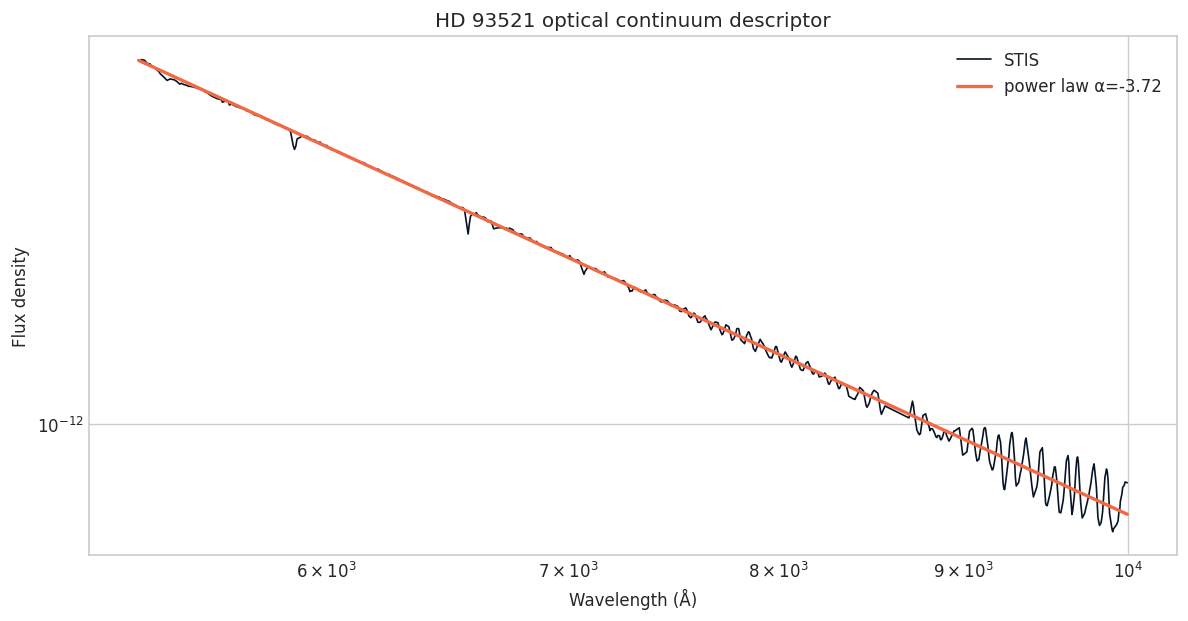

In [4]:
model=np.exp(np.polyval(coef,np.log(spec.wavelength_A))); fig,ax=plt.subplots(figsize=(10,5.3)); ax.loglog(spec.wavelength_A,spec.flux,color=COLORS["navy"],lw=1,label="STIS"); ax.loglog(spec.wavelength_A,model,color=COLORS["orange"],lw=2,label=f"power law α={slope:.2f}"); ax.set(xlabel="Wavelength (Å)",ylabel="Flux density",title="HD 93521 optical continuum descriptor"); ax.legend(); fig.tight_layout(); fig.savefig("hd93521_continuum_slope.png",dpi=180); plt.show()

In [5]:
s20=float(fit_slope(20)[0][0]); s50=float(fit_slope(50)[0][0]); print(f"mask widths 20/35/50 Å: {s20:.3f}, {slope:.3f}, {s50:.3f}")

mask widths 20/35/50 Å: -3.715, -3.716, -3.716


In [6]:
result={"id":"2026-07-31-hst-stis-continuum-slope","title":"HST/STIS continuum slope of HD 93521","archive":"MAST · HST","date":"2026-07-31","question":"What power law describes the optical continuum?","sample_size":int(keep.sum()),"results":[f"Fλ exponent {slope:.3f}",f"bootstrap 68% {lo:.3f}–{hi:.3f}",f"20–50 Å masks give {s20:.3f} to {s50:.3f}"],"validation":"Strong-line mask widths of 20, 35, and 50 Å are compared.","notebook":"mast/2026-07-31-hst-stis-continuum-slope/notebook.ipynb","hero":"mast/2026-07-31-hst-stis-continuum-slope/hd93521_continuum_slope.png","tags":["HST","STIS","continuum"]}; Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['Fλ exponent -3.716', 'bootstrap 68% -3.727–-3.697', '20–50 Å masks give -3.715 to -3.716']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- MAST data acknowledgement and citation guidance: https://archive.stsci.edu/publishing/
- STIS Data Handbook: https://hst-docs.stsci.edu/stisdhb
- STIS flux and wavelength accuracy limits: https://hst-docs.stsci.edu/stisdhb/chapter-4-stis-error-sources/4-3-factors-limiting-flux-and-wavelength-accuracy

The spectrum is a calibrated STIS product. The M87 JPEG is explicitly treated
as a display preview; physical photometry requires calibrated FITS data, WCS,
exposure information, and point-spread-function treatment.